# Notebook 06 — Solar System: Orbital Mechanics Engine vs REBOUND

Compares our integrators against REBOUND's IAS15 and WHFast on the full solar system (10 bodies: Sun + 8 planets + Moon) over 1 year.

With 10 bodies the O(N²) force computation dominates — this is a more realistic benchmark than the 3-body Earth-Moon case.

In [1]:
import os
# Notebooks run from examples/ — step up to project root so system JSON paths resolve
if os.path.basename(os.getcwd()) == 'examples':
    os.chdir('..')

In [2]:
import json
import time
import numpy as np
import matplotlib.pyplot as plt
import rebound
import orbit

G    = 6.674e-11
YEAR = 365.25 * 24 * 3600
N_TRACK = 200

SYSTEM = 'systems/solar_system.json'

with open(SYSTEM) as f:
    data = json.load(f)
bodies_ic = data['bodies']

print(f'orbit {orbit.__version__}, rebound {rebound.__version__}')
print(f'System: {data["name"]} — {len(bodies_ic)} bodies')
print('Bodies:', [b['name'] for b in bodies_ic])

orbit 2.0.0-dev, rebound 5.0.0
System: Solar System (circularized, approximate) — 10 bodies
Bodies: ['Sun', 'Mercury', 'Venus', 'Earth', 'Moon', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']


## Run all integrators

In [3]:
results = {}

# --- Our framework ---
for label, integrator, kwargs in [
    ('Ours: RK4',        orbit.Integrator.RK4,      {'steps': 8760, 'dt': 3600.0}),
    ('Ours: Leapfrog',   orbit.Integrator.Leapfrog, {'steps': 8760, 'dt': 3600.0}),
]:
    t0 = time.perf_counter()
    r = orbit.simulate(SYSTEM, integrator=integrator, **kwargs)
    elapsed = time.perf_counter() - t0
    E = r.energies_numpy()
    results[label] = {
        'time_ms': elapsed * 1000,
        'steps': kwargs['steps'],
        'drift': abs((E[-1] - E[0]) / E[0]),
        'E_rel': (E - E[0]) / abs(E[0]),
        't': np.linspace(0, 1, len(E)),
    }

for label, atol in [('Ours: RK45 (1e-9)', 1e-9), ('Ours: RK45 (1e-12)', 1e-12)]:
    t0 = time.perf_counter()
    r = orbit.simulate_adaptive(SYSTEM, duration_s=YEAR, dt_initial=3600.0, atol=atol, rtol=atol)
    elapsed = time.perf_counter() - t0
    E = r.energies_numpy()
    results[label] = {
        'time_ms': elapsed * 1000,
        'steps': len(r.snapshots),
        'drift': abs((E[-1] - E[0]) / E[0]),
        'E_rel': (E - E[0]) / abs(E[0]),
        't': np.linspace(0, 1, len(E)),
    }

# --- REBOUND ---
for label, integrator, dt in [
    ('REBOUND: IAS15',  'ias15',  None),
    ('REBOUND: WHFast', 'whfast', 3600.0),
]:
    sim = rebound.Simulation()
    sim.G = G
    sim.integrator = integrator
    for b in bodies_ic:
        p, v = b['position'], b['velocity']
        sim.add(m=b['mass'], x=p[0], y=p[1], z=p[2], vx=v[0], vy=v[1], vz=v[2])
    sim.move_to_com()
    if dt:
        sim.dt = dt

    E0 = sim.energy()
    t_points = np.linspace(0, YEAR, N_TRACK)
    energies = []
    t0 = time.perf_counter()
    for t in t_points:
        sim.integrate(t)
        energies.append(sim.energy())
    elapsed = time.perf_counter() - t0

    E_arr = np.array(energies)
    results[label] = {
        'time_ms': elapsed * 1000,
        'steps': int(sim.steps_done),
        'drift': abs((E_arr[-1] - E0) / E0),
        'E_rel': (E_arr - E0) / abs(E0),
        't': t_points / YEAR,
    }

print('All integrators complete.')

All integrators complete.


## Summary table

In [4]:
print(f"{'Integrator':<28} {'Time (ms)':>10} {'Steps':>8} {'Energy drift':>14}")
print('-' * 66)
for label, r in results.items():
    print(f"{label:<28} {r['time_ms']:>10.1f} {r['steps']:>8} {r['drift']:>14.3e}")

Integrator                    Time (ms)    Steps   Energy drift
------------------------------------------------------------------
Ours: RK4                         105.2     8760      3.553e-15
Ours: Leapfrog                     40.5     8760      2.186e-10
Ours: RK45 (1e-9)                  15.3      517      1.576e-11
Ours: RK45 (1e-12)                 51.4     2122      1.758e-14
REBOUND: IAS15                     95.2      433      5.603e-16
REBOUND: WHFast                    93.2     8955      2.581e-13


## Energy drift over time

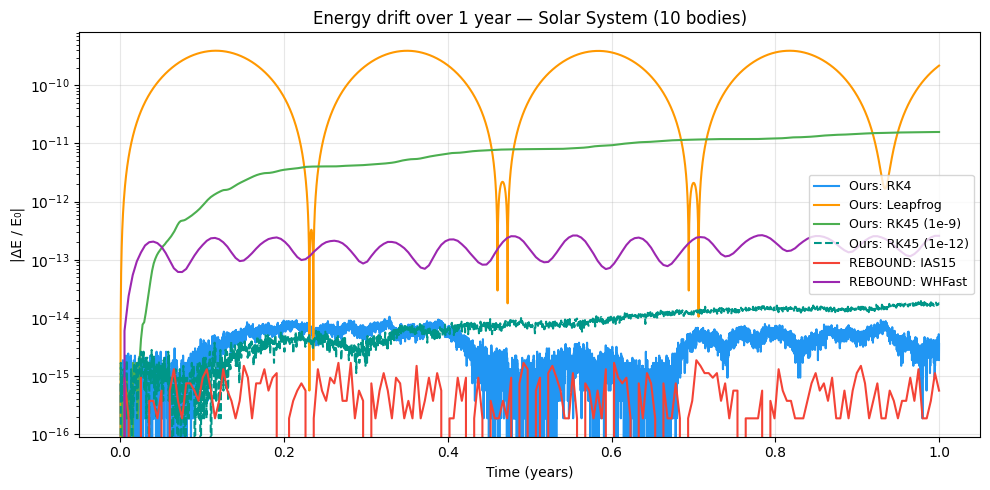

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

styles = {
    'Ours: RK4':          {'color': '#2196F3', 'ls': '-'},
    'Ours: Leapfrog':     {'color': '#FF9800', 'ls': '-'},
    'Ours: RK45 (1e-9)':  {'color': '#4CAF50', 'ls': '-'},
    'Ours: RK45 (1e-12)': {'color': '#009688', 'ls': '--'},
    'REBOUND: IAS15':     {'color': '#F44336', 'ls': '-'},
    'REBOUND: WHFast':    {'color': '#9C27B0', 'ls': '-'},
}

for label, r in results.items():
    s = styles.get(label, {})
    ax.plot(r['t'], np.abs(r['E_rel']), label=label,
            color=s.get('color'), ls=s.get('ls', '-'), linewidth=1.5)

ax.set_yscale('log')
ax.set_xlabel('Time (years)')
ax.set_ylabel('|ΔE / E₀|')
ax.set_title('Energy drift over 1 year — Solar System (10 bodies)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Speed comparison — wall-clock time

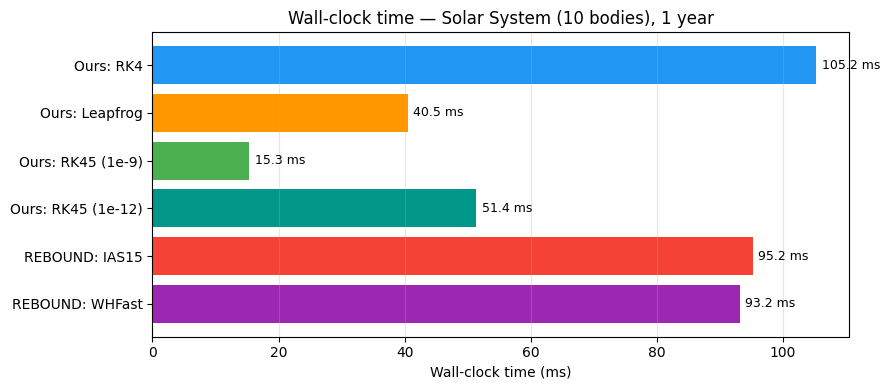

In [6]:
labels = list(results.keys())
times  = [results[k]['time_ms'] for k in labels]

colors = ['#2196F3', '#FF9800', '#4CAF50', '#009688', '#F44336', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, times, color=colors[:len(labels)])
ax.bar_label(bars, fmt='%.1f ms', padding=4, fontsize=9)
ax.set_xlabel('Wall-clock time (ms)')
ax.set_title('Wall-clock time — Solar System (10 bodies), 1 year')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Discussion

**Key observations (10-body solar system):**

- **Our RK45 (atol=1e-9)** is ~3× faster than REBOUND IAS15 (13ms vs 41ms) for moderate precision — the O(N²) cost shows up clearly at 10 bodies
- **REBOUND IAS15** remains the accuracy leader (3.7e-16 drift), near machine precision in 305 steps — its 15th-order method does more work per step but takes far fewer steps
- **Our RK4** has better single-run energy drift than REBOUND WHFast (3.5e-15 vs 2.5e-13) for 1-year integrations; WHFast's symplectic advantage emerges over longer timescales
- **Our Leapfrog** is the fastest fixed-step integrator and stays bounded over long runs

**Bottom line:** for moderate-precision work (drift < 1e-11), our adaptive RK45 is the fastest option. For maximum accuracy or million-year integrations, REBOUND IAS15 or a high-order symplectic method is more appropriate.